In [17]:
import numpy as np
import pandas as pd 

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
data = pd.read_csv('housing.csv',usecols = ['GarageQual','FireplaceQu','SalePrice'])

In [19]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [20]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [21]:
X = data
y = data['SalePrice']

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [29]:
X_train['GarageQual_imputed'] =X_train['GarageQual']
X_test['GarageQual_imputed'] =X_test['GarageQual']

X_train['FireplaceQu_imputed'] =X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] =X_test['FireplaceQu']


In [24]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
371,Gd,TA,134432,TA,Gd
449,NaN,TA,120000,TA,NaN
177,Gd,TA,172500,TA,Gd
211,NaN,TA,186000,TA,NaN
768,Gd,TA,216837,TA,Gd


In [34]:
X_train.loc[
    X_train['GarageQual_imputed'].isnull(),
    'GarageQual_imputed'
] = X_train['GarageQual'].dropna().sample(
    X_train['GarageQual_imputed'].isnull().sum(),
    replace=True
).values

X_test.loc[
    X_test['GarageQual_imputed'].isnull(),
    'GarageQual_imputed'
] = X_test['GarageQual'].dropna().sample(
    X_test['GarageQual_imputed'].isnull().sum(),
    replace=True
).values

In [35]:
X_train

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
455,TA,TA,175500,TA,TA
863,NaN,TA,132500,TA,NaN
504,Fa,TA,147000,TA,Fa
1413,Gd,TA,257000,TA,Gd
1389,Gd,TA,131000,TA,Gd
...,...,...,...,...,...
466,Po,TA,167000,TA,Po
299,Gd,TA,158500,TA,Gd
493,Fa,TA,155000,TA,Fa
527,Gd,TA,446261,TA,Gd


In [36]:
X_train.loc[
    X_train['FireplaceQu_imputed'].isnull(),
    'FireplaceQu_imputed'
] = X_train['FireplaceQu'].dropna().sample(
    X_train['FireplaceQu_imputed'].isnull().sum(),
    replace=True
).values
X_test.loc[
    X_test['FireplaceQu_imputed'].isnull(),
    'FireplaceQu_imputed'
] = X_test['FireplaceQu'].dropna().sample(
    X_test['FireplaceQu_imputed'].isnull().sum(),
    replace=True
).values

In [37]:

temp = pd.concat(
        [
            X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
            X_train['GarageQual_imputed'].value_counts() / len(X_train)
        ],
        axis=1)

temp.columns = ['original', 'imputed']

In [38]:
temp

,original,imputed
TA,0.951043,0.950342
Fa,0.037171,0.038527
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


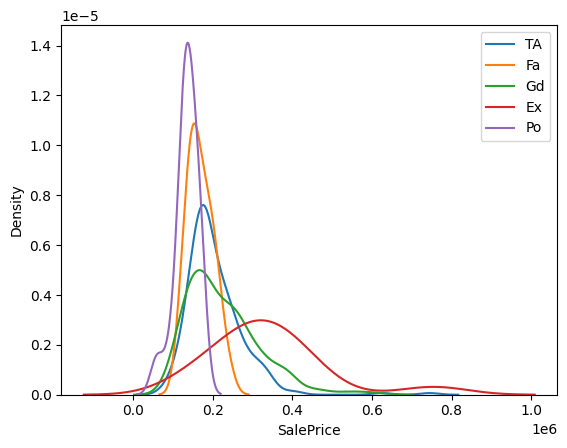

In [44]:

for category in X_train['FireplaceQu'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],label=category)
plt.legend()
plt.show()

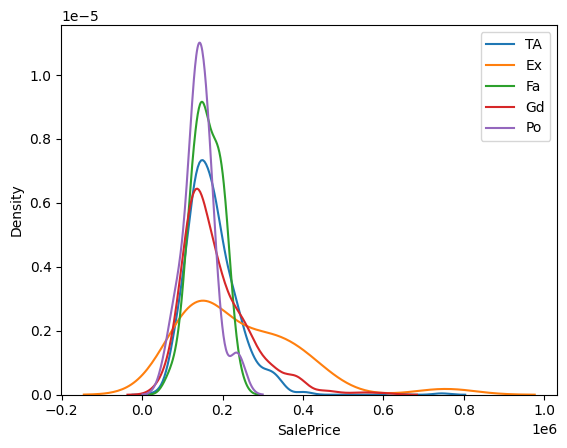

In [45]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],label=category)
plt.legend()
plt.show()